In [1]:
import tensorly as tl
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()

In [2]:
from moabb.paradigms import P300,LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler



paradigm = LeftRightImagery()
dataset = BNCI2014004()


epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
    subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

BNCI2014004 has been renamed to BNCI2014_004. BNCI2014004 will be removed in version 1.1.
The dataset class name 'BNCI2014004' must be an abbreviation of its code 'BNCI2014-004'. See moabb.datasets.base.is_abbrev for more information.


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
720 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 120 events (all good), 3 – 7.5 s (baseline off), ~3.1 MB, data loaded,
 'left_hand': 60
 'right_hand': 60>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 160 events (all good), 3 – 7.5 s (baseline off), ~4.1 MB, data loaded,
 'left_hand': 80
 'right_hand': 80>
  warn(f"warnEpochs {epochs}")
/usr

In [11]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor
import numpy as np
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], normalize=True, log=False)
X = tl.tensor(X)
y = labels
X.shape

(120, 3, 16, 72)

/tmp/ipykernel_15022/1921624324.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x)


<Axes: ylabel='Density'>

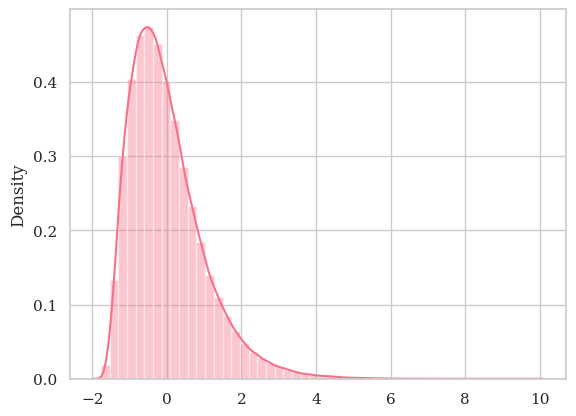

In [12]:
import seaborn as sns
x = X.flatten()
x = tl.to_numpy(x)
sns.distplot(x)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/5, random_state=2)

In [14]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[1]*10,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
%time bttda.fit(X_train,y_train)

Fitting block 1/10...


Forward model :   9%|▊         | 11/128 [00:00<00:00, 123.85it/s]


Fitting block 2/10...


Forward model :  45%|████▍     | 57/128 [00:00<00:00, 158.74it/s]


Fitting block 3/10...


...

Forward model :  70%|██████▉   | 89/128 [00:00<00:00, 141.89it/s]


Fitting block 10/10...


Forward model :  30%|██▉       | 38/128 [00:00<00:00, 116.56it/s]

CPU times: user 22.4 s, sys: 87.4 ms, total: 22.5 s
Wall time: 22.6 s


BTTDA(extra_train_info=True,
      hoda_params={'delta': None, 'extra_train_info': False, 'init': 'random',
                   'max_iter': 128, 'obj': 'tr', 'random_state': 42, 'rank': 1,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': False,
                   'toeplitz': None, 'tol': 1e-08, 'verbose': True},
      ranks=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], verbose=True)

In [15]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,log_loss,mse,nmse
0,1,"(1, 1, 1)",0.069459,0.136024,2.828856e-03,0.999908,0.981954
1,2,"(1, 1, 1)",0.045837,0.175865,5.187481e-05,0.997110,0.979206
2,3,"(1, 1, 1)",0.043596,0.302686,1.200328e-06,0.995382,0.977509
3,4,"(1, 1, 1)",0.038266,0.322839,2.815571e-08,0.994034,0.976185
4,5,"(1, 1, 1)",0.036651,0.383110,6.808586e-10,0.992778,0.974952
5,6,"(1, 1, 1)",0.034064,0.395108,4.404212e-10,0.982849,0.965201
6,7,"(1, 1, 1)",0.032967,0.425246,2.168929e-11,0.963411,0.946113
7,8,"(1, 1, 1)",0.030730,0.430133,1.206510e-11,0.961518,0.944253
8,9,"(1, 1, 1)",0.029687,0.440821,4.018340e-12,0.956421,0.939248
9,10,"(1, 1, 1)",0.028913,0.451023,1.940337e-12,0.952896,0.935787


<Axes: xlabel='block', ylabel='nmse'>

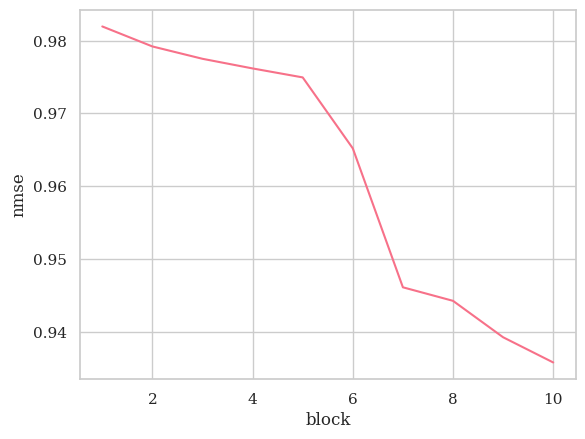

In [16]:
import seaborn as sns
sns.lineplot(data=df, x='block', y='nmse')

,mse,nmse,block
0,0.915524,0.987765,0
1,0.914077,0.986203,1
2,0.917656,0.990064,2
3,0.917849,0.990273,3
4,0.919038,0.991556,4
5,0.910462,0.982303,5
6,0.888029,0.958100,6
7,0.885502,0.955374,7
8,0.886737,0.956706,8
9,0.885081,0.954919,9


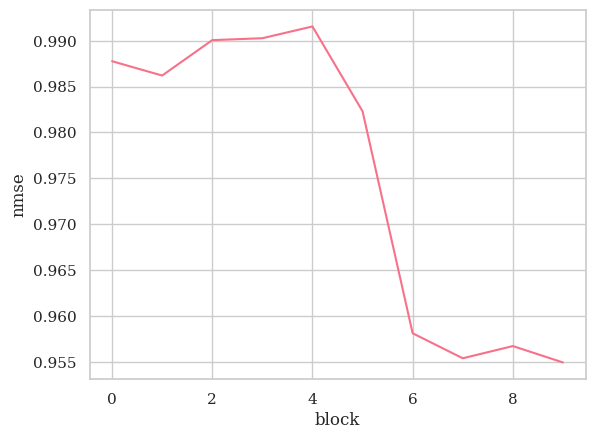

In [17]:
from hoda.hoda import forward_stats
info = []
for b in range(len(bttda.blocks_)):
    Xt_test = bttda.transform(X_test, blocks=bttda.blocks_[:b+1])
    X_rec_test = bttda.inv_transform(Xt_test, n_blocks=b+1)
    res = forward_stats(X_test, Xt_test, X_rec_test,y)
    res['block'] =b
    info.append(res)
info = pd.DataFrame(info)
sns.lineplot(data=info, x='block', y='nmse')
info